In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Diana Morgan - 336472261, Oded Katz - 211862693

In [23]:
data = pd.read_csv("../PA1/imputed_data.csv")

In [41]:
data

,gender_0male_1female,age_YEARS,diabetes,hypertension,COPD,PVD,CKD,IHD,AF,VHD,...,platelets,bilirubin,potassium,length_of_stay_DAYS,time_discharge_to_death_MONTHS,death,survival_status,n_comorbidities,cat_comorbidities,delta_BUN
0,0,48.85803,0,0,0,0,0,0,0,0,...,178.0,1.090,3.9,0.456785,5.000000,1,Event: death observed within follow-up,0,0-1,-1.0
1,0,49.67481,0,0,0,0,0,0,0,0,...,114.0,5.765,4.8,0.245513,0.700000,1,Event: death observed within follow-up,0,0-1,0.0
2,0,85.35892,0,0,0,0,0,0,0,0,...,289.0,0.520,4.0,1.632458,8.033333,1,Event: death observed within follow-up,0,0-1,1.0
3,0,52.80388,0,0,0,0,0,0,0,0,...,188.0,0.550,6.1,5.921769,0.033333,1,Event: death observed within follow-up,0,0-1,1.7
4,0,67.30150,0,0,0,0,0,0,0,0,...,274.0,0.500,5.3,17.214475,20.433333,0,Censored: no death observed within follow-up,0,0-1,-31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3956,1,79.89901,1,1,1,0,0,1,0,0,...,166.0,0.400,4.4,4.992978,36.000000,0,Censored: no death observed within follow-up,5,4+,-8.0
3957,1,81.62935,1,1,1,0,0,1,1,0,...,345.0,0.290,3.9,5.082924,36.000000,0,Censored: no death observed within follow-up,6,4+,-12.0
3958,1,81.17655,1,1,1,0,0,1,1,0,...,351.0,0.300,4.0,5.977934,36.000000,0,Censored: no death observed within follow-up,6,4+,-3.0
3959,1,63.80359,1,1,1,0,0,1,1,0,...,188.6,0.640,4.4,4.016553,36.000000,0,Censored: no death observed within follow-up,6,4+,4.0


## Section 1

In [24]:
# constructing the categorical comorbidity variable
comorbidity_columns = ['diabetes', 'hypertension', 'COPD', 'PVD', 'CKD', 'IHD', 'AF', 'VHD', 'PHTN']
data['n_comorbidities'] = data[comorbidity_columns].sum(axis=1)
data['cat_comorbidities'] = pd.cut(data['n_comorbidities'], bins=[0, 1, 3, np.inf], include_lowest=True, labels=['0-1', '2-3', '4+'])

In [25]:
# fit cox prop hazard model

from lifelines import CoxPHFitter

cph = CoxPHFitter()
formula = ("gender_0male_1female + age_YEARS + C(cat_comorbidities) + "
           "length_of_stay_DAYS + BUN_discharge + creatinine_discharge + GFR_discharge + "
           "BNP + WBC + sodium + RDW + platelets + bilirubin + potassium")
cph.fit(data, 
             duration_col='time_discharge_to_death_MONTHS', 
             event_col='death', 
             formula=formula)
cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(4).sort_values(by="p")

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0429,1.0373,1.0485,0.0000
BUN_discharge,1.0157,1.0127,1.0188,0.0000
sodium,0.9712,0.9611,0.9813,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
RDW,1.1304,1.1004,1.1613,0.0000
length_of_stay_DAYS,1.0106,1.0049,1.0164,0.0003
bilirubin,1.1305,1.0143,1.2599,0.0266
platelets,1.0003,0.9998,1.0009,0.2003
potassium,0.9483,0.8721,1.0313,0.2150


The main findings are that age, BUN (at discharge), sodium, BNP, RDW, bilirubin and length of stay are significant predictors of mortality, with RDW and bilirubin having the strongest effects as they increase the risk of mortality by 13% times for each unit increase. The other variables have a smaller effect on mortality.

Another important finding is that the number of comorbidities is not a significant predictor of mortality in any level (with 0-1 as refrence level, 2-3 and 4+ are not significant). This suggests that the presence of comorbidities alone may not be a strong predictor of mortality, and that other factors such as age and lab values may be more important in determining mortality risk.

## Section 2

In [26]:
cph.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 15
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
         731.35 <0.005    483.05

The likelihood ratio test comes out significant, so we reject the null hypothesis that all coefficients are equal to zero. This means that at least one of the covariates is significantly associated with the hazard of mortality.

## Section 3

In [27]:
data['delta_BUN'] = data['BUN_discharge'] - data['BUN_admission']

### (a)

In [28]:
data['delta_BUN'].describe()

count    3961.000000
mean        3.124383
std        14.898313
min       -83.000000
25%        -3.000000
50%         3.000000
75%         9.800000
max       208.300000
Name: delta_BUN, dtype: float64

<Axes: >

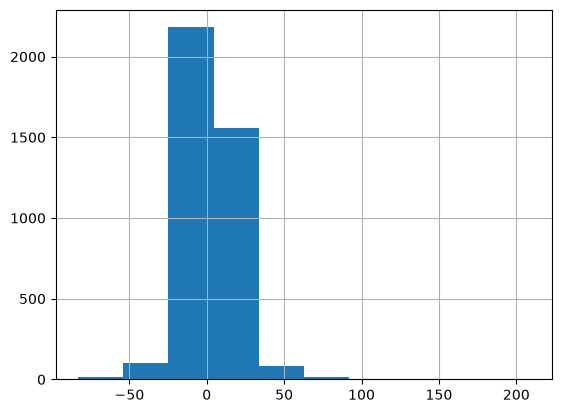

In [29]:
data['delta_BUN'].hist()

### (b)

BUN is the amount of urea nitrogen in the blood, which is a waste product from protein digestion. High BUN levels can indicate kidney dysfunction or dehydration, which can increase the risk of mortality. Low BUN levels are less common and usually not serious. Positive delta_BUN values indicate an increase in BUN levels from admission to discharge, which may suggest worsening kidney function or dehydration during hospitalization. Negative delta_BUN values indicate a decrease in BUN levels, which may suggest improvement in kidney function or hydration status.

### (c)

In [30]:
bun_cph = CoxPHFitter()
bun_formula = formula + " + delta_BUN"
bun_cph.fit(data, 
             duration_col='time_discharge_to_death_MONTHS', 
             event_col='death', 
             formula=bun_formula)

<lifelines.CoxPHFitter: fitted with 3961 total observations, 2282 right-censored observations>

### (d)

$H_0: \beta_{\text{delta\_BUN}} = 0$: The coefficient of delta_BUN is equal to zero (no effect on mortality)

$H_1: \beta_{\text{delta\_BUN}} \neq 0$: The coefficient of delta_BUN is not equal to zero (has an effect on mortality)

In [31]:
from scipy import stats

lr = 2 * (bun_cph.log_likelihood_ - cph.log_likelihood_)
lr_pv = 1 - stats.chi2.cdf(lr, df=1)

print(f"Full log-likelihood: {bun_cph.log_likelihood_:.4f}")
print(f"Reduced log-likelihood: {cph.log_likelihood_:.4f}")
print(f"LR statistic: {lr:.4f}")
print(f"Degrees of freedom: 1")
print(f"p-value: {lr_pv:.4g}")

Full log-likelihood: -12896.5511
Reduced log-likelihood: -12910.3640
LR statistic: 27.6257
Degrees of freedom: 1
p-value: 1.472e-07


The likelihood ratio test comes out significant, so we reject the null hypothesis that the coefficient of delta_BUN is equal to zero. This means that delta_BUN is significantly associated with the hazard of mortality, and that changes in BUN levels from admission to discharge may be an important predictor of mortality risk. Therefore we should include it in our analysis.

### (e)

As the likelihood ratio test came out significant, it means that the change in BUN during hospitalization provides prognostic information beyond the patient’s condition at discharge.

## Section 4

In [32]:
s = bun_cph.baseline_survival_
s[s.index <= 12].values[-1]

array([0.78418695])

This is the one-year baseline survival probability, obtained by taking the exponential of the negative of the baseline cumulative hazard at 12 months. The  baseline cumulative hazard is obtained from Breslow estimator:
$$\hat{H}_0(t) = \sum_{i: Y_i \le t} \frac{1}{\sum_{j \in R(Y_i)} e^{\hat{\beta}^T x_j}}$$

So the baseline survival probability at 12 months is:
$$\hat{S}_0(12) = e^{-\hat{H}_0(12)}$$

In [33]:
def baseline_x(data):
    baseline = {}
    for col in data.columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            baseline[col] = [data[col].median()]   # median, not mean
        else:
            baseline[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(baseline)


def cond_survival_prob(cph, t, x_df):
    """
    x_df: a 1-row DataFrame in the ORIGINAL covariate space (not dummy-encoded).
    lifelines handles encoding internally via predict_log_partial_hazard.
    """
    # Breslow baseline survival at time t
    s0 = cph.baseline_survival_
    s0_at_t = s0[s0.index <= t].iloc[-1, 0]   # scalar

    # log partial hazard = X^T beta, correctly encoded by lifelines
    log_ph = cph.predict_log_partial_hazard(x_df).values[0]   # scalar

    return s0_at_t ** np.exp(log_ph)


def plot_survival_by_covariate(cph, data, covariate, t=12.0, values=None):
    base = baseline_x(data)   # 1-row DataFrame

    if values is None:
        if pd.api.types.is_numeric_dtype(data[covariate]):
            values = np.linspace(data[covariate].min(), data[covariate].max(), 100)
        else:
            values = data[covariate].unique()
    values = np.sort(values)

    probs = []
    for v in values:
        x = base.copy()
        x[covariate] = v
        probs.append(cond_survival_prob(cph, t, x))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(values, probs)
    ax.set_xlabel(covariate)
    ax.set_ylabel(f"Estimated {t}-month survival probability")
    ax.set_title(f"{t}-month survival by {covariate}\n(all other covariates at median/mode)")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

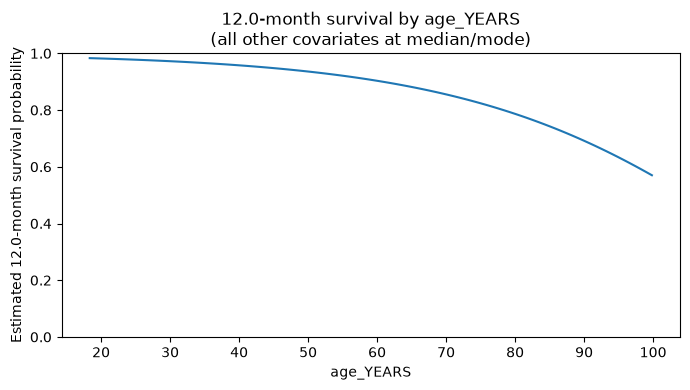

In [34]:
plot_survival_by_covariate(bun_cph, data, 'age_YEARS', t=12.0)

The age of the patient has a modest negative effect on the one-year survival probability, with older patients having a lower probability of surviving one year. The effect is not very strong, as it decline steadily from 1 to 0.8.

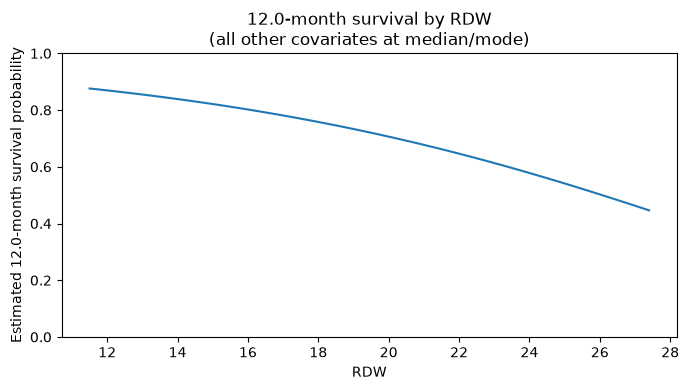

In [35]:
plot_survival_by_covariate(bun_cph, data, 'RDW', t=12.0)

RDW also has a somewhat modest negative effect, but with a steeper decline in survival probability as RDW increases. The effect is more pronounced than age, with survival probability dropping from 0.9 to 0.5 as RDW increases.

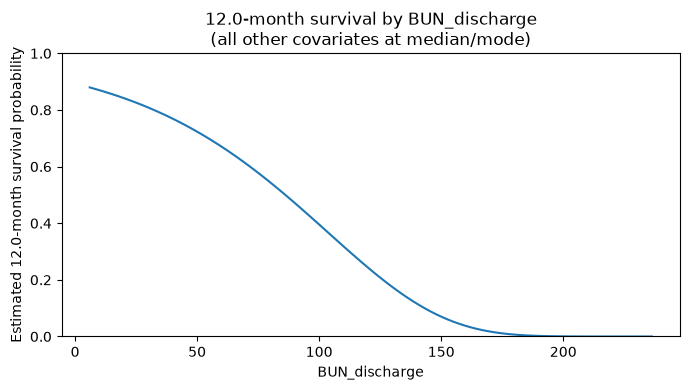

In [36]:
plot_survival_by_covariate(bun_cph, data, 'BUN_discharge', t=12.0)

The BUN at discharge has a more interesting effect, with a sharp decline in survival probability as BUN increases. Extremely high BUN values (above 50) are associated with a very low probability of surviving one year, while lower BUN values (below 20) are associated with a high probability of survival. This suggests that BUN at discharge is a strong predictor of mortality risk, and that patients with high BUN levels may require closer monitoring and intervention to improve their chances of survival.

## Section 5

In [37]:
selected_cph = bun_cph
selected_formula = bun_formula

In [ ]:
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(
    selected_cph,
    data,
    time_transform="rank"
)

ph_summary = ph_test.summary.sort_values("p")
ph_summary

,test_statistic,p,-log2(p)
BUN_discharge,4.391749,0.036113,4.791328
length_of_stay_DAYS,3.911381,0.047960,4.382019
creatinine_discharge,2.739764,0.097879,3.352853
C(cat_comorbidities)[T.4+],2.700408,0.100323,3.317282
bilirubin,2.453830,0.117239,3.092481
sodium,1.643281,0.199876,2.322823
C(cat_comorbidities)[T.2-3],1.387631,0.238806,2.066091
gender_0male_1female,1.268597,0.260030,1.943250
age_YEARS,1.064034,0.302297,1.725962
GFR_discharge,0.827774,0.362917,1.462288


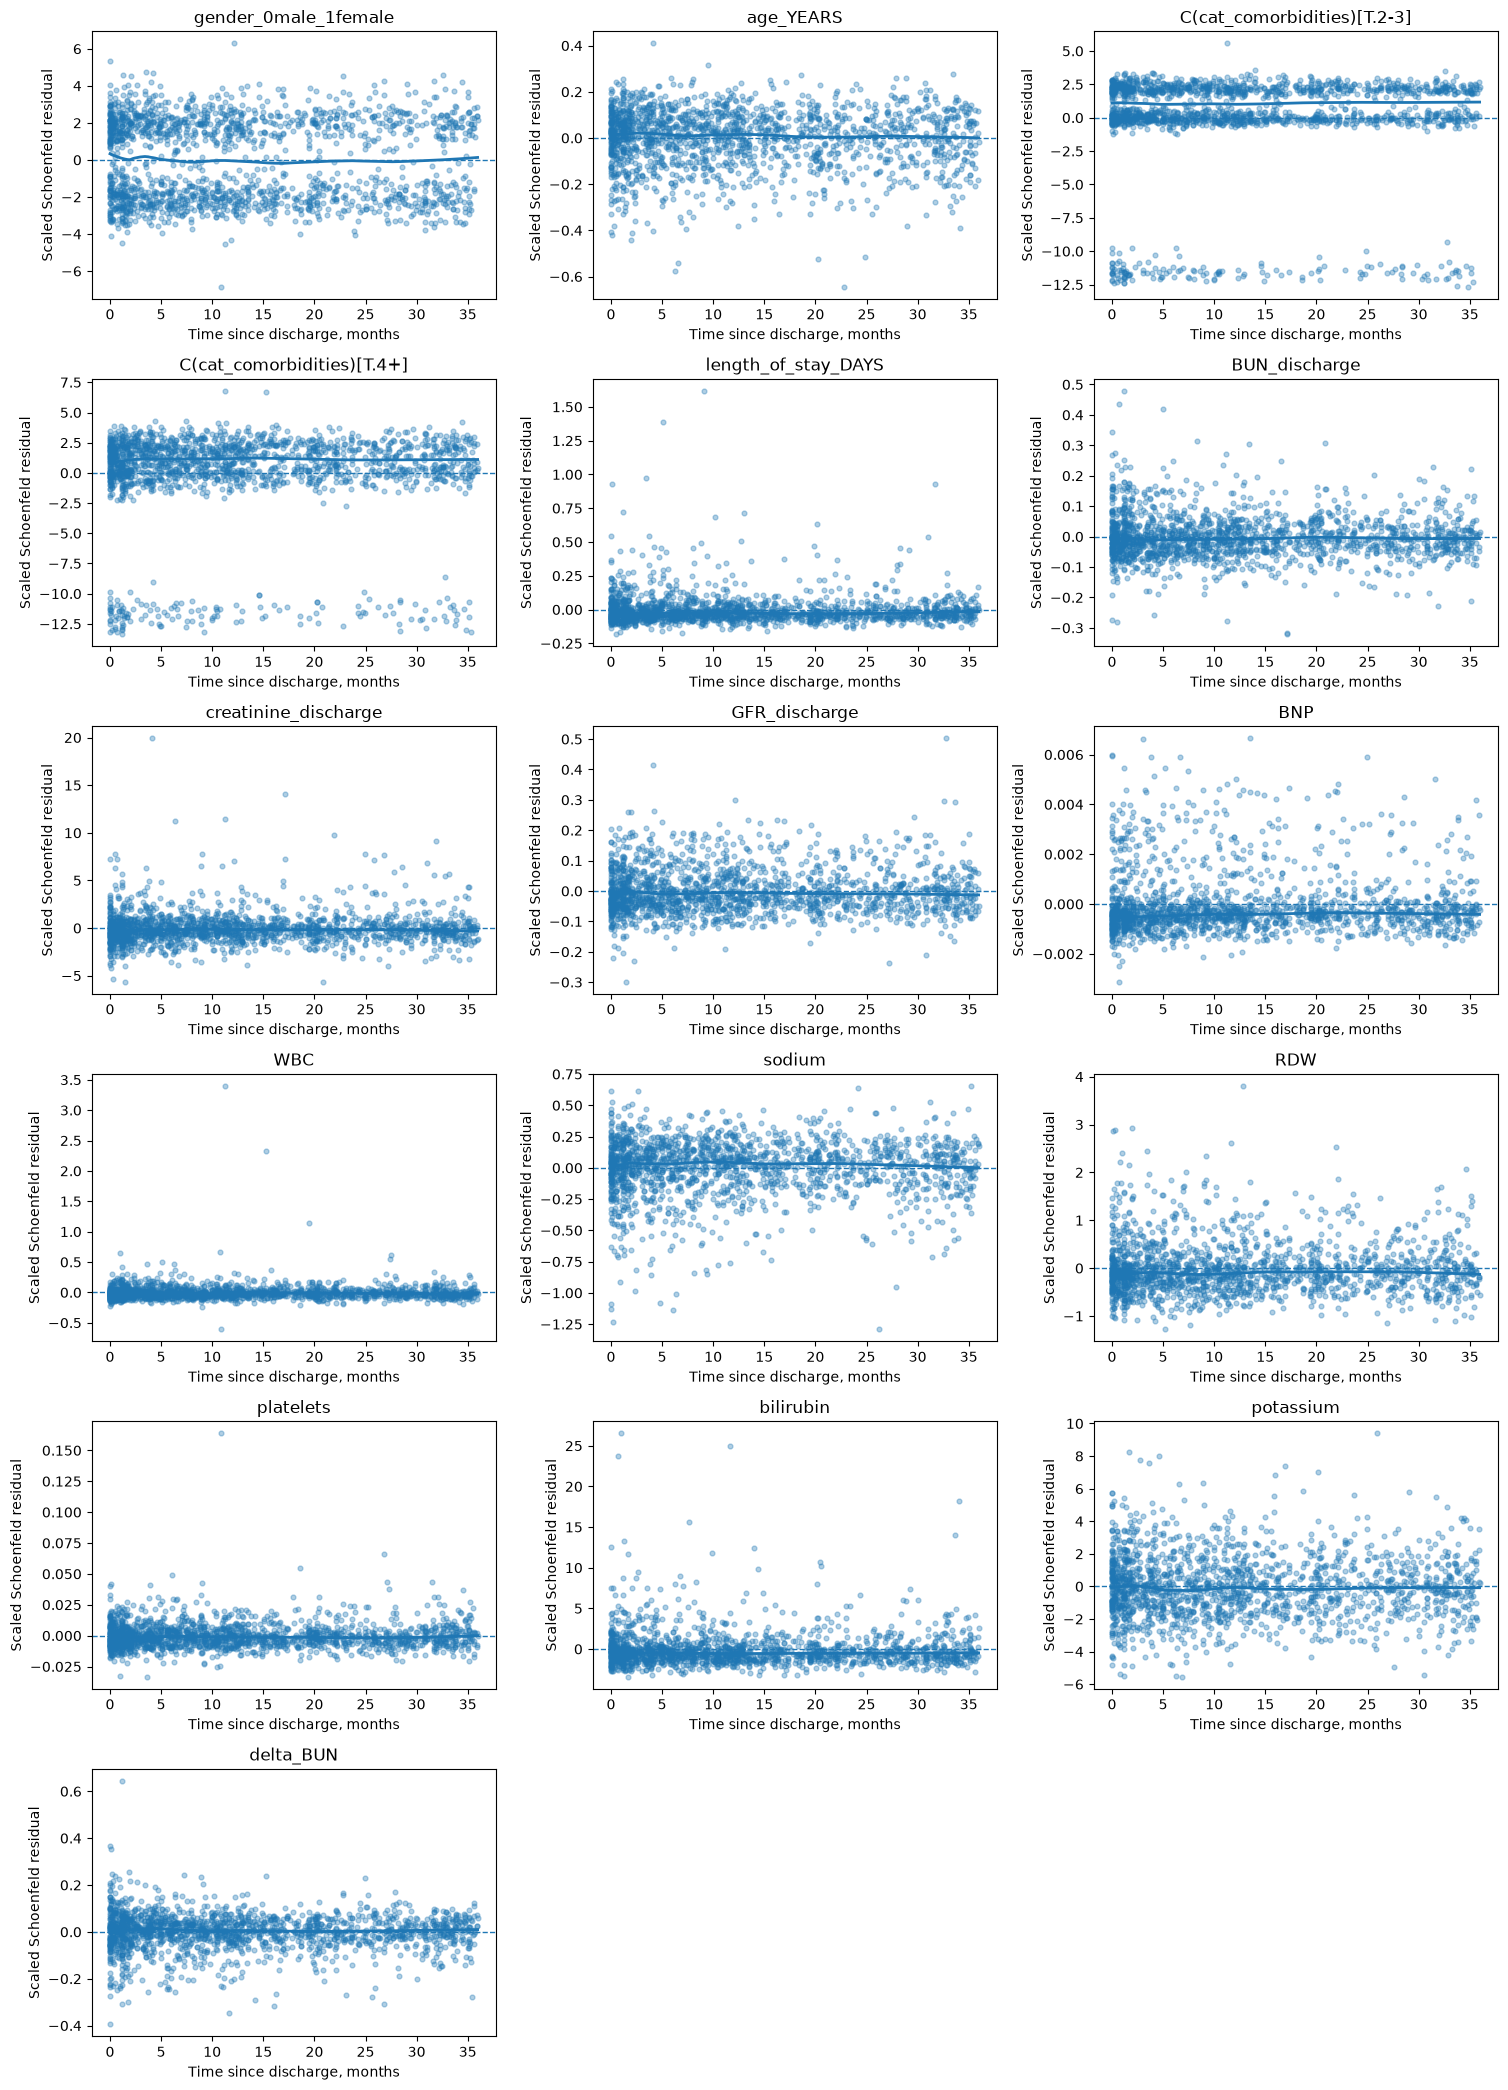

In [ ]:
import math
from statsmodels.nonparametric.smoothers_lowess import lowess

schoenfeld_resids = selected_cph.compute_residuals(
    data,
    kind="scaled_schoenfeld"
)

event_times = data.loc[schoenfeld_resids.index, "time_discharge_to_death_MONTHS"]

n_covariates = len(schoenfeld_resids.columns)
n_cols = 3
n_rows = math.ceil(n_covariates / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    sharex=False
)

axes = axes.flatten()

for ax, covariate in zip(axes, schoenfeld_resids.columns):
    x = event_times.values
    y = schoenfeld_resids[covariate].values
    
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    
    ax.scatter(x_sorted, y_sorted, alpha=0.35, s=12)
    ax.axhline(0, linestyle="--", linewidth=1)
    
    smoothed = lowess(y_sorted, x_sorted, frac=0.3, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2)
    
    ax.set_title(covariate)
    ax.set_xlabel("Time since discharge, months")
    ax.set_ylabel("Scaled Schoenfeld residual")

for j in range(len(schoenfeld_resids.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The formal Schoenfeld tests suggested possible violations for BUN_discharge and length_of_stay_DAYS, since both had p-values below 0.05. For the other covariates there was no significant evidence against the proportional hazards assumption.

The plots mostly showed residuals scattered around zero. For BUN_discharge and length_of_stay_DAYS, there may be mild trends, but they are not very visually strong. The comorbidity plots look somewhat unusual because the variable is categorical and enters the model as dummy variables, so the residuals form bands. This does not by itself suggest a violation.

Overall, the formal tests suggest mild possible violations, but the graphical evidence is not very clear or severe. The model therefore seems mostly acceptable, but the hazard ratios for BUN_discharge and length_of_stay_DAYS should be interpreted as approximate average effects over follow-up time, rather than effects that are perfectly constant at all times.



## Section 6

In [42]:
from lifelines import LogNormalAFTFitter

selected_cph = bun_cph
selected_formula = bun_formula

aft_data = data.copy()
small_time = 0.01  # about 0.01 months, only used to avoid log(0)

aft_data.loc[
    aft_data["time_discharge_to_death_MONTHS"] <= 0,
    "time_discharge_to_death_MONTHS"
] = small_time

aft = LogNormalAFTFitter()

aft.fit(
    aft_data,
    duration_col="time_discharge_to_death_MONTHS",
    event_col="death",
    formula=selected_formula
)

aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 3961 total observations, 2282 right-censored observations>
             duration col = 'time_discharge_to_death_MONTHS'
                event col = 'death'
   number of observations = 3961
number of events observed = 1679
           log-likelihood = -7921.24
         time fit was run = 2026-07-03 13:20:24 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                    
mu_    Intercept                    6.39    593.96      1.66            3.14            9.64               23.00            15338.74
       gender_0male_1female        -0.08      0.93      0.10           -0.27            0.12                0.76                1.12
       age_YEARS                   -0.07      0.94      0.00           -0.07           -0.06                0.93                0.95
       C(cat_comorbidities)[T.2-3]  0.36      1.43      0.16            0.04            0.68                1.04                1.97
       C(cat_comorbidities)[T.4+]   0.23      1.26      0.17           -0.10            0.56                0.91                1.75
       length_of_stay_DAYS         -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
       BUN_discharge               -0.04      0.96      0.00           -0.05           -0.04                0.95                0.97
       creatinine_discharge         0.19      1.22      0.08            0.04            0.35                1.04                1.43
       GFR_discharge               -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
       BNP                         -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       WBC                          0.00      1.00      0.01           -0.01            0.01                0.99                1.01
       sodium                       0.05      1.05      0.01            0.03            0.07                1.03                1.07
       RDW                         -0.19      0.83      0.03           -0.24           -0.13                0.79                0.88
       platelets                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       bilirubin                   -0.27      0.77      0.10           -0.47           -0.06                0.62                0.94
       potassium                    0.08      1.08      0.08           -0.08            0.23                0.93                1.26
       delta_BUN                    0.02      1.02      0.00            0.01            0.02                1.01                1.02
sigma_ Intercept                    0.88      2.40      0.02            0.84            0.91                2.32                2.49

                                    cmp to      z      p  -log2(p)
param  covariate                                                  
mu_    Intercept                      0.00   3.85 <0.005     13.05
       gender_0male_1female           0.00  -0.77   0.44      1.18
       age_YEARS                      0.00 -14.14 <0.005    148.46
       C(cat_comorbidities)[T.2-3]    0.00   2.19   0.03      5.14
       C(cat_comorbidities)[T.4+]     0.00   1.38   0.17      2.57
       length_of_stay_DAYS            0.00  -3.68 <0.005     12.08
       BUN_discharge                  0.00 -11.49 <0.005     99.16
       creatinine_discharge           0.00   2.39   0.02      5.91
       GFR_discharge                  0.00  -0.25   0.80      0.32
       BNP                            0.00  -4.54 <0.005     17.46
       WBC                            0.00   0.25   0.80      0.32
       sodium                         0.00   4.93 <0.005     20.21
       RDW                            0.00

In [43]:
aft_summary = aft.summary.loc["mu_"]
aft_summary[["coef", "exp(coef)", "se(coef)", "p"]]

,coef,exp(coef),se(coef),p
covariate,,,,
Intercept,6.386816,593.962640,1.658867,1.180664e-04
gender_0male_1female,-0.075545,0.927238,0.098429,4.427812e-01
age_YEARS,-0.065202,0.936878,0.004610,2.032457e-45
C(cat_comorbidities)[T.2-3],0.358427,1.431076,0.163555,2.841703e-02
C(cat_comorbidities)[T.4+],0.229776,1.258318,0.166890,1.685706e-01
length_of_stay_DAYS,-0.020503,0.979706,0.005568,2.310316e-04
BUN_discharge,-0.042871,0.958035,0.003730,1.412285e-30
creatinine_discharge,0.194858,1.215138,0.081383,1.665141e-02
GFR_discharge,-0.000807,0.999194,0.003185,8.000477e-01


In [44]:
model_vars = [
    "gender_0male_1female",
    "age_YEARS",
    "cat_comorbidities",
    "length_of_stay_DAYS",
    "BUN_discharge",
    "creatinine_discharge",
    "GFR_discharge",
    "BNP",
    "WBC",
    "sodium",
    "RDW",
    "platelets",
    "bilirubin",
    "potassium",
    "delta_BUN"
]

def representative_patient(data, model_vars):
    row = {}
    for col in model_vars:
        if pd.api.types.is_numeric_dtype(data[col]):
            row[col] = [data[col].median()]
        else:
            row[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(row)


def cox_surv_1yr(row):
    surv = selected_cph.predict_survival_function(row, times=[12])
    return surv.iloc[0, 0]


def aft_surv_1yr(row):
    surv = aft.predict_survival_function(row, times=[12])
    return surv.iloc[0, 0]

In [47]:
def compare_cox_aft_plot(covariate, data, model_vars, n_points=100):
    base = representative_patient(data, model_vars)
    
    values = np.linspace(
        data[covariate].min(),
        data[covariate].max(),
        n_points
    )
    
    cox_probs = []
    aft_probs = []
    
    for value in values:
        row = base.copy()
        row[covariate] = value
        
        cox_probs.append(cox_surv_1yr(row))
        aft_probs.append(aft_surv_1yr(row))
    
    plt.figure(figsize=(7, 5))
    plt.plot(values, cox_probs, label="Cox model")
    plt.plot(values, aft_probs, label="Log-normal AFT model")
    plt.xlabel(covariate)
    plt.ylabel("Predicted one-year survival probability")
    plt.title(f"One-year survival prediction by {covariate}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

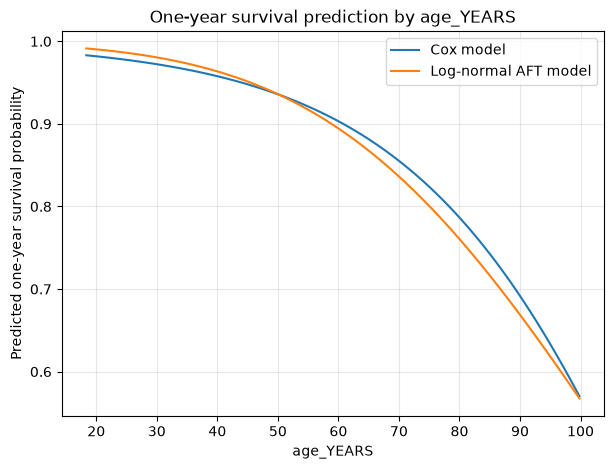

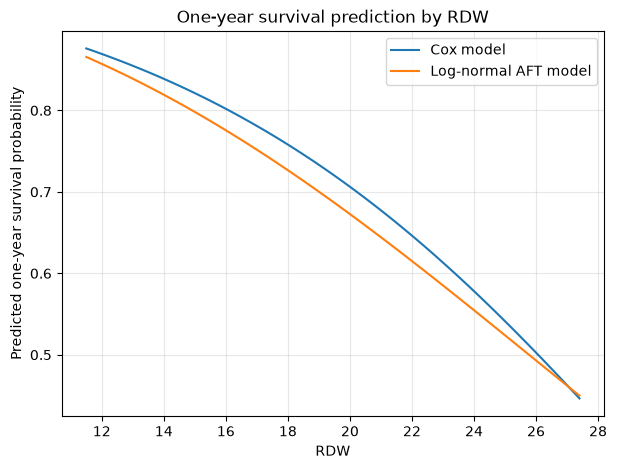

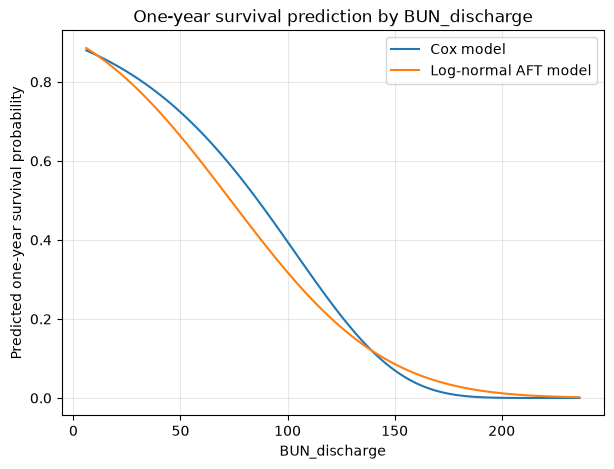

In [48]:
compare_cox_aft_plot("age_YEARS", data, model_vars)
compare_cox_aft_plot("RDW", data, model_vars)
compare_cox_aft_plot("BUN_discharge", data, model_vars)

The log-normal AFT model was fitted with the same covariates as the selected Cox model. Unlike the Cox model, the AFT model does not model the hazard directly, but survival time. In this model, a positive coefficient means longer predicted survival time, while a negative coefficient means shorter predicted survival time. So the direction of interpretation is different from the Cox model, where a positive coefficient means a higher hazard.

The AFT results were broadly consistent with the Cox model. Age, discharge BUN, RDW, bilirubin, and length of stay had negative coefficients, meaning that higher values were associated with shorter predicted survival. Sodium and the 2-3 comorbidity category had positive coefficients, meaning longer predicted survival time in this fitted model. The 4+ comorbidity category was not clearly significant.

The one-year prediction plots compare the Cox and log-normal AFT models. For age, both models show lower predicted one-year survival as age increases. The two curves are very similar, with only small differences. For RDW, both models again show decreasing one-year survival with higher RDW, with the AFT model giving slightly lower predictions across much of the range. For discharge BUN, both models show a strong decrease in predicted one-year survival as BUN increases. Here the difference between the models is more visible, especially at higher BUN values, but the overall direction is the same.


## Section 7

## 7. Final discussion

The main factors associated with post-discharge survival were age, discharge BUN, RDW, bilirubin, and length of stay. In the Cox model, higher values of these variables were generally associated with worse survival. This was also visible in the prediction plots: older age, higher RDW, and especially higher discharge BUN were linked to lower predicted one-year survival.

The change in BUN during hospitalization also appeared to add prognostic information. Adding delta_BUN to the Cox model significantly improved model fit in the likelihood-ratio test, so the change in BUN seems to provide information beyond the patient’s BUN level at discharge alone. 

The proportional hazards diagnostics showed mild possible violations for BUN_discharge and length_of_stay_DAYS. The formal Schoenfeld tests were significant for these variables, but the residual plots did not show very strong or obvious trends. Overall, the proportional hazards assumption seems mostly reasonable, but should be used with caution.

The Cox and log-normal AFT models gave similar main conclusions. Both models predicted lower one-year survival with increasing age, RDW, and discharge BUN. The predicted probabilities were not identical, but the direction of the effects was stable across both models. This supports the main clinical interpretation that worse discharge laboratory values and older age are associated with poorer post-discharge survival.